# Scenario risk quantification for "leading vehicle decelerating"

In [1]:
# Do the necessary imports
from copy import deepcopy
import os
import numpy as np
import pandas as pd
from domain_model import DocumentManagement
from simulation import SimulationLeadBraking, acc_lead_braking_pars, acc_idm_lead_braking_pars, \
    IDMPlus, ACC, ACCIDMPlus, KDE, kde_from_file
from case_study import get_kpi, case_study, CaseStudy, sample_reactiontime, reactiontime_density

In [2]:
# By default, do not overwrite previous results. Set to True to rerun all simulations.
OVERWRITE = True

# Drone data (True) or ERP2017 data (False)
drone = True

## Several simulations

Below, two simulations are performed. One in which the ego vehicle is controlled by the ACC, and one in which the human (modelled using IDM+) can take over. Note the difference in the acceleration after around 3 seconds: this is the point where the human takes over control.

array([2.0430039])

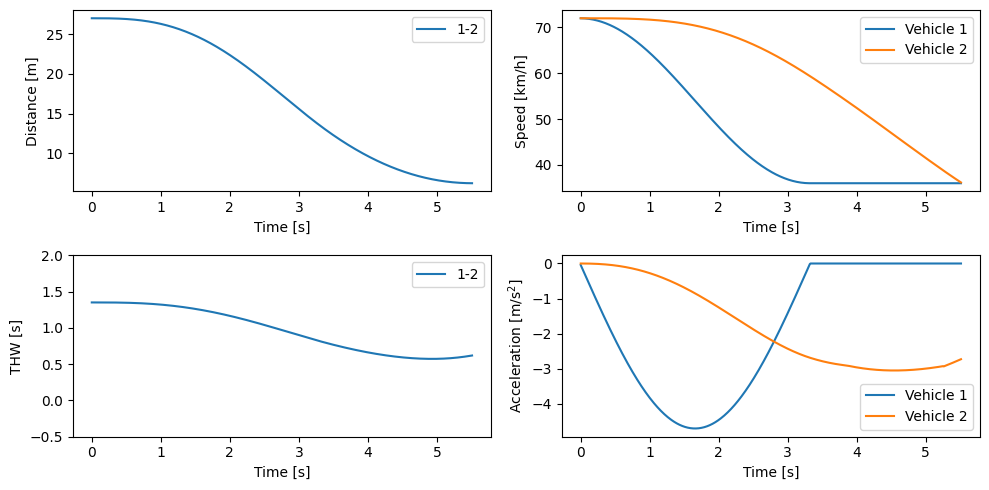

In [3]:
simulator_acc = SimulationLeadBraking(follower=ACC(), follower_parameters=acc_lead_braking_pars,
                                      min_simulation_time=5)
simulator_acc.simulation(dict(v0=20, amean=3, dv=10), plot=True)

array([2.19055846])

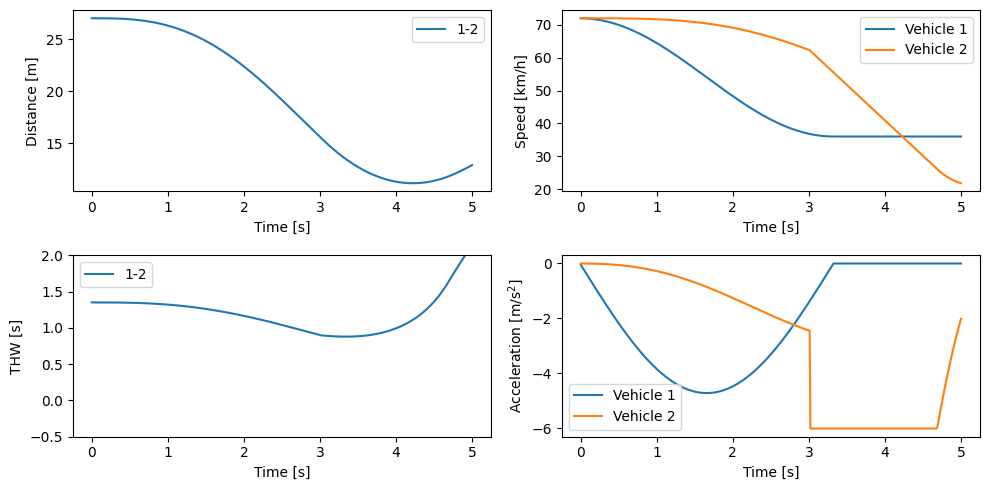

In [4]:
simulator_accidm = SimulationLeadBraking(follower=ACCIDMPlus(), 
                                         follower_parameters=acc_idm_lead_braking_pars,
                                         min_simulation_time=5)
simulator_accidm.simulation(dict(v0=20, amean=3, dv=10, reactiontime=1), plot=True)

Let's now limit the deceleration of the ego vehicle. The minimum distance/TTC becomes a bit lower, but not yet something to worry about.

array([2.10771588])

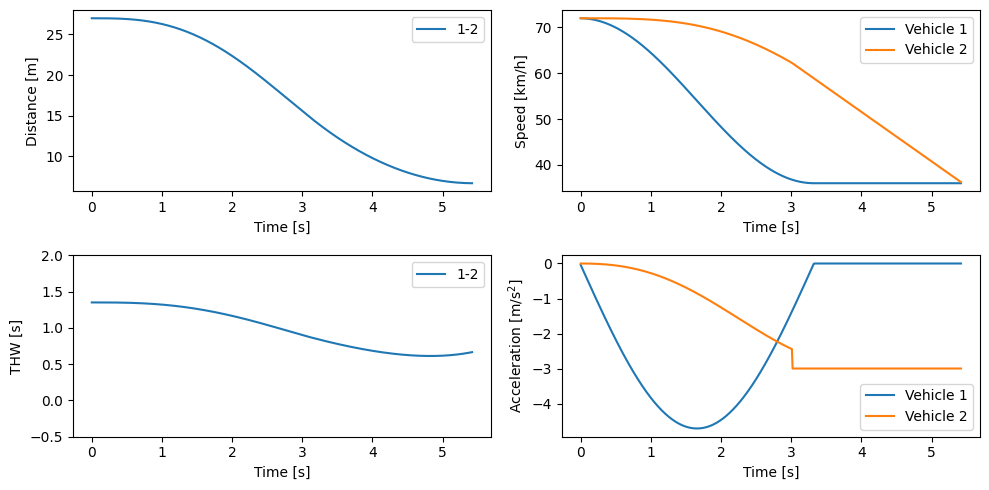

In [5]:
simulator_accidm.simulation(dict(v0=20, amean=3, dv=10, reactiontime=1, amin=-3), plot=True)

Let's limit the viewing range of the ego vehicle. This only has an effect if we limit the viewing range extremely, because the leading vehicle is always quite close. Note that the driver now takes over at about 4 seconds into the simulation instead of 3 seconds.

array([2.0430039])

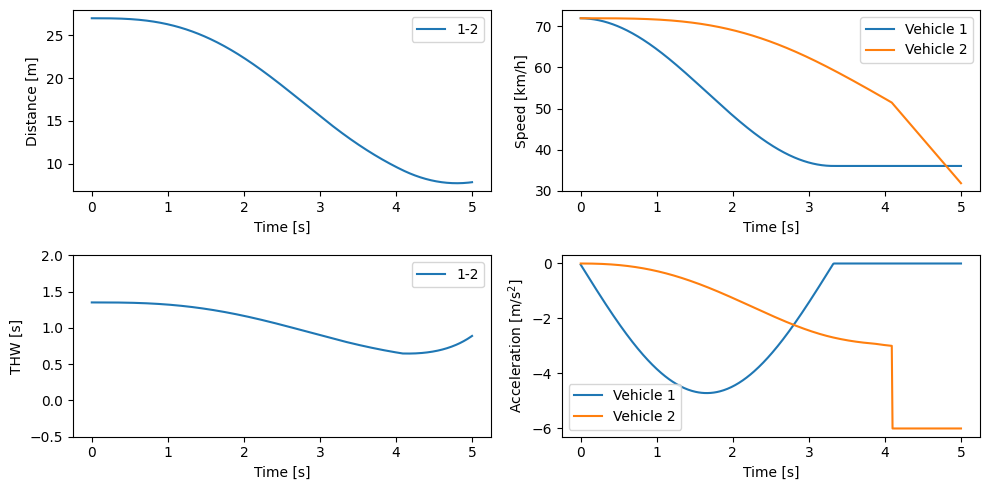

In [6]:
simulator_accidm.simulation(dict(v0=20, amean=3, dv=10, reactiontime=1, max_view=15), plot=True)

## Create KDE of scenario parameters

In [9]:
filename = os.path.join("data", "kde", "leading_vehicle_decelerating.p")
if os.path.exists(filename) and not OVERWRITE:
    kde = kde_from_file(filename)
else:
    pars_df = pd.read_parquet(os.path.join("data", "scenarios", "leading_vehicle_braking_pars_df.parquet"))
    pars = pars_df.values.tolist()
    kde = KDE(np.array(pars))
    kde.compute_bandwidth()
    kde.pickle(filename)

c:\GIT\ScenarioRiskQuantification\simulation\fastkde.py:495: RuntimeWarning: divide by zero encountered in log
  score = (np.sum(np.log(np.sum(np.exp(self.data_helpers.mindists


## Perform the case study

#### Some functions that are needed

In [10]:
# Function that checks if the scenario parameters are valid.
def check_pars(pars):
    if pars[2] <= 0 or pars[2] > pars[0] or pars[1] <= 0:  # dv<0, vend>=0, amean>0
        return False
    if len(pars) > 3 and pars[3] <= 0:
        return False
    return True

# Function for sampling the parameters in case the ACC model is used.
def func_sample_acc():
    return kde.sample()[0]

# Function for sampling the parameters in case the ACCIDMPlus model is used.
def func_sample_accidmplus():
    return np.concatenate((kde.sample()[0], [sample_reactiontime()]))

# Function for obtaining the pdf of the parameters in case the ACC model is used.
def func_density_acc(pars):
    return kde.score_samples(pars)

# Function for obtaining the pdf of the parameters in case the ACCIDMPlus model is used.
def func_density_accidm(pars):
    return kde.score_samples(pars[:, :3]) * reactiontime_density(pars[:, 3])

#### With ACC, no triggering condition

In [11]:
default_parameters = dict(n=10000,
                          default_parameters=dict(amin=-6),
                          percentile=2,
                          func_validity_check=check_pars,
                          func_process_result=get_kpi)

In [12]:
pars_acc = dict(name="leading_vehicle_decelerating_acc",
                parameters=["v0", "amean", "dv"],
                simulator=simulator_acc,
                func_sample=func_sample_acc,
                func_density=func_density_acc)
pars_acc.update(default_parameters)
df_mc, df_is = case_study(CaseStudy(**pars_acc), overwrite=OVERWRITE)

100%|██████████| 10000/10000 [00:43<00:00, 232.36it/s]


Monte Carlo:


AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

#### With ACC & IDM+, no triggering condition

In [ ]:
pars_accidm = dict(name="leading_vehicle_decelerating_accidm",
                   parameters=["v0", "amean", "dv", "reactiontime"],
                   simulator=simulator_accidm,
                   func_sample=func_sample_accidmplus,
                   func_density=func_density_accidm)
pars_accidm.update(default_parameters)
df_mc, df_is = case_study(CaseStudy(**pars_accidm), overwrite=OVERWRITE)

#### With ACC, triggering condition: low $\mu$

In [ ]:
AMIN = -3  # Corresponding to mu=0.3

In [ ]:
pars = deepcopy(pars_acc)
pars["default_parameters"] = dict(amin=AMIN)
pars["name"] = "lowmu_leading_vehicle_decelerating_acc"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)

#### With ACC & IDM+, triggering condition: low $\mu$

In [ ]:
pars = deepcopy(pars_accidm)
pars["default_parameters"].update(dict(amin=AMIN))
pars["name"] = "lowmu_leading_vehicle_decelerating_accidm"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)

#### With ACC, triggering condition: low visibility

Result is exactly the same as without this triggering condition, so no need to redo the simulations

In [ ]:
MAX_VIEW = 60  # [m]

In [ ]:
df_mc, df_is = case_study(CaseStudy(**pars_acc), overwrite=False)

#### With ACC & IDM+, triggering condition: low visibility

In [ ]:
pars = deepcopy(pars_accidm)
pars["default_parameters"].update(dict(max_view=MAX_VIEW))
pars["name"] = "late_leading_vehicle_decelerating_accidm"
df_mc, df_is = case_study(CaseStudy(**pars), overwrite=OVERWRITE)